Convert yolo type dataset to coco for faster rcnn


In [3]:
import os
import json
from PIL import Image

def yolo_to_coco(image_dir, label_dir, output_json, class_names):
    images = []
    annotations = []
    categories = []
    ann_id = 1

    for i, cls in enumerate(class_names):
        categories.append({"id": i + 1, "name": cls, "supercategory": "none"})

    img_id = 1
    for img_file in os.listdir(image_dir):
        if not img_file.endswith((".jpg", ".png", ".jpeg")):
            continue

        img_path = os.path.join(image_dir, img_file)
        label_path = os.path.join(label_dir, os.path.splitext(img_file)[0] + ".txt")

        with Image.open(img_path) as img:
            w, h = img.size

        images.append({
            "id": img_id,
            "file_name": img_file,
            "width": w,
            "height": h
        })

        if os.path.exists(label_path):
            with open(label_path) as f:
                for line_num, line in enumerate(f, 1):
                    parts = line.strip().split()
                    if len(parts) < 5:
                        print(f"Skipping line {line_num} in {label_path}: Not enough values.")
                        continue
                    try:
                        cls_id, xc, yc, bw, bh = map(float, parts[:5])
                    except ValueError:
                        print(f"Skipping line {line_num} in {label_path}: ValueError parsing floats.")
                        continue

                    x = (xc - bw / 2) * w
                    y = (yc - bh / 2) * h
                    width = bw * w
                    height = bh * h

                    annotations.append({
                        "id": ann_id,
                        "image_id": img_id,
                        "category_id": int(cls_id) + 1,
                        "bbox": [x, y, width, height],
                        "area": width * height,
                        "iscrowd": 0
                    })
                    ann_id += 1

        img_id += 1

    coco_format = {
        "images": images,
        "annotations": annotations,
        "categories": categories
    }

    with open(output_json, 'w') as f:
        json.dump(coco_format, f, indent=4)

    print(f"COCO annotations saved to: {output_json}")

# Example usage
class_names = ["speed_bump"]
yolo_to_coco("../data/train/images", "../data/train/labels", "../data/annotations_train.json", class_names)
yolo_to_coco("../data/valid/images", "../data/valid/labels", "../data/annotations_val.json", class_names)


COCO annotations saved to: dataset/annotations_train.json
COCO annotations saved to: dataset/annotations_val.json


Faster RCNN Model Training

In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from pycocotools.coco import COCO
from PIL import Image
import os

class COCODataset(CocoDetection):
    def __getitem__(self, index):
        img, target = super().__getitem__(index)
        w, h = img.size

        boxes = []
        labels = []

        for ann in target:
            if ann.get('iscrowd', 0) == 1:
                continue
            x, y, width, height = ann['bbox']
            if width <= 0 or height <= 0:
                continue
            boxes.append([x, y, x + width, y + height])
            labels.append(ann['category_id'])

        if len(boxes) == 0:
            return self.__getitem__((index + 1) % len(self))

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([index])
        }

        img = F.to_tensor(img)
        return img, target

def collate_fn(batch):
    return tuple(zip(*batch))

def get_model(num_classes):
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn(weights=weights)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
        in_features, num_classes
    )
    return model

def train():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    dataset = COCODataset("../data/train/images", "../data/annotations_train.json")
    data_loader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)

    model = get_model(num_classes=2) 
    model.to(device)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

    for epoch in range(10):
        model.train()
        total_loss = 0
        for i, (images, targets) in enumerate(data_loader):
            images = list(img.to(device) for img in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            try:
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())

                optimizer.zero_grad()
                losses.backward()
                optimizer.step()
                total_loss += losses.item()
            except Exception as e:
                print(f"Skipping batch {i} due to error: {e}")
                continue

        print(f"Epoch {epoch + 1} Loss: {total_loss:.4f}")

    torch.save(model.state_dict(), "../models/faster_rcnn/fasterrcnn_speedbump.pth")
    print("Model saved as fasterrcnn_speedbump.pth")

if __name__ == "__main__":
    train()


loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Epoch 1 Loss: 497.1781
Epoch 2 Loss: 333.2903
Epoch 3 Loss: 284.1719
Epoch 4 Loss: 264.4309
Epoch 5 Loss: 251.6839
Epoch 6 Loss: 249.7751
Epoch 7 Loss: 241.1115
Epoch 8 Loss: 271.9430
Epoch 9 Loss: 258.2872
Epoch 10 Loss: 237.1116
Model saved as fasterrcnn_speedbump.pth


Predicting single image

c:\Users\faizj\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\faizj\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


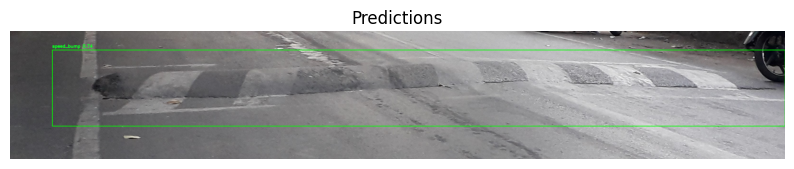


 Image: 1025.jpg
 Inference time: 564.13 ms
 FPS: 1.77 frames/sec
 Detections above 0.5: 1


In [ ]:
import torch
import torchvision
import cv2
import time
from torchvision.transforms import functional as F
from PIL import Image
import matplotlib.pyplot as plt

model_path = "../models/faster_rcnn/fasterrcnn_speedbump_tuned.pth"
image_path = "1025.jpg" 
class_names = ["speed_bump"]
conf_thresh = 0.5

def get_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model(num_classes=2)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

img_pil = Image.open(image_path).convert("RGB")
img_tensor = F.to_tensor(img_pil).unsqueeze(0).to(device)

start_time = time.time()
with torch.no_grad():
    output = model(img_tensor)[0]
end_time = time.time()

inference_time = (end_time - start_time) * 1000  
fps = 1000 / inference_time if inference_time > 0 else 0

img_cv = cv2.imread(image_path)
num_detections = 0

for box, score, label in zip(output['boxes'], output['scores'], output['labels']):
    if score < conf_thresh:
        continue
    num_detections += 1
    x1, y1, x2, y2 = map(int, box.cpu().numpy())
    label_name = class_names[label - 1] if label > 0 and label <= len(class_names) else str(label)
    cv2.rectangle(img_cv, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(img_cv, f"{label_name} {score:.2f}", (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (36, 255, 12), 2)

img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title("Predictions")
plt.show()

print(f"\n Image: {image_path}")
print(f" Inference time: {inference_time:.2f} ms")
print(f" FPS: {fps:.2f} frames/sec")
print(f" Detections above {conf_thresh}: {num_detections}")


Evaluating Model Performance

In [ ]:
import torch
import torchvision
from torchvision.datasets import CocoDetection
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import DataLoader
from pycocotools.cocoeval import COCOeval
from pycocotools.coco import COCO
import os
import numpy as np
from PIL import Image
import json

class COCODataset(CocoDetection):
    def __getitem__(self, index):
        img, target = super().__getitem__(index)
        w, h = img.size

        boxes = []
        labels = []

        for ann in target:
            x, y, width, height = ann['bbox']
            boxes.append([x, y, x + width, y + height])
            labels.append(ann['category_id'])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([index])
        }

        img = F.to_tensor(img)
        return img, target

def collate_fn(batch):
    return tuple(zip(*batch))

def get_model(num_classes):
    model = fasterrcnn_resnet50_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def evaluate():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    dataset = COCODataset("../data/valid/images", "../data/annotations_val.json")
    data_loader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

    model = get_model(num_classes=2)  # 1 class + background
    model.load_state_dict(torch.load("../models/faster_rcnn/fasterrcnn_speedbump_tuned.pth", map_location=device))
    model.to(device)
    model.eval()

    coco_gt = dataset.coco
    coco_results = []

    unmatched_files = []
    filename_to_id = {v["file_name"]: k for k, v in coco_gt.imgs.items()}

    print("Running evaluation...")
    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]
            outputs = model(images)

            for i, output in enumerate(outputs):
                image_index = targets[i]["image_id"].item()
                image_id = dataset.ids[image_index]
                image_filename = dataset.coco.imgs[image_id]["file_name"]

                if image_filename not in filename_to_id:
                    unmatched_files.append(image_filename)
                    continue

                boxes = output['boxes'].cpu().numpy()
                scores = output['scores'].cpu().numpy()
                labels = output['labels'].cpu().numpy()

                for box, score, label in zip(boxes, scores, labels):
                    x1, y1, x2, y2 = box
                    coco_box = [x1, y1, x2 - x1, y2 - y1]
                    coco_results.append({
                        "image_id": int(image_id),
                        "category_id": int(label),
                        "bbox": [float(x) for x in coco_box],
                        "score": float(score)
                    })

    if unmatched_files:
        print("\n⚠️ Unmatched files (not found in annotation JSON):")
        for fname in unmatched_files:
            print(f" - {fname}")
        return

    if not coco_results:
        print("No detections found.")
        return

    results_file = "fasterrcnn_results.json"
    with open(results_file, "w") as f:
        json.dump(coco_results, f, indent=4)

    coco_dt = coco_gt.loadRes(results_file)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    metrics = coco_eval.stats
    map_50_95 = metrics[0]
    map_50 = metrics[1]
    precision = map_50
    recall = metrics[6]

    f1_score = 2 * (precision * recall) / (precision + recall) if precision + recall > 0 else 0.0

    print("\n📊 Evaluation Metrics:")
    print(f"mAP@0.5      : {map_50:.4f}")
    print(f"mAP@0.5:0.95 : {map_50_95:.4f}")
    print(f"Precision    : {precision:.4f}")
    print(f"Recall       : {recall:.4f}")
    print(f"F1-score     : {f1_score:.4f}")

if __name__ == "__main__":
    evaluate()


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Running evaluation...
Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.31s).
Accumulating evaluation results...
DONE (t=0.15s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.626
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.970
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.723
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.123
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.540
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.645
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.622
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.694
 Average Recall     (AR) @[ IoU=0.50:0.95 |

In [ ]:
import torch
import torchvision
from torchvision.datasets import CocoDetection
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision import transforms as T
from torch.utils.data import DataLoader
import os
import numpy as np
from PIL import Image
import json


def get_train_transform():
    return T.Compose([
        T.RandomHorizontalFlip(0.5),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        T.ToTensor()
    ])

def get_valid_transform():
    return T.Compose([T.ToTensor()])

class COCODataset(CocoDetection):
    def __init__(self, img_folder, ann_file, transforms=None):
        super().__init__(img_folder, ann_file)
        self.custom_transforms = transforms

    def __getitem__(self, index):
        img, target = super().__getitem__(index)

        if len(target) == 0:
            return self.__getitem__((index + 1) % len(self))

        boxes = []
        labels = []

        for ann in target:
            x, y, width, height = ann['bbox']
            boxes.append([x, y, x + width, y + height])
            labels.append(ann['category_id'])

        if len(boxes) == 0:
            return self.__getitem__((index + 1) % len(self))

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([index])
        }

        if self.custom_transforms:
            img = self.custom_transforms(img)  

        return img, target


def collate_fn(batch):
    return tuple(zip(*batch))


def get_model(num_classes):
    model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


def train_model():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    train_dataset = COCODataset("../data/train/images", "../data/annotations_train.json", transforms=get_train_transform())
    valid_dataset = COCODataset("../data/valid/images", "../data/annotations_val.json", transforms=get_valid_transform())

    train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
    valid_loader = DataLoader(valid_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

    model = get_model(num_classes=2) 
    model.to(device)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
    lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    num_epochs = 10
    print("Starting training...")

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for images, targets in train_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            epoch_loss += losses.item()

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

        lr_scheduler.step()
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

    torch.save(model.state_dict(), "../models/faster_rcnn/fasterrcnn_speedbump_tuned.pth")
    print("Model saved as fasterrcnn_speedbump_tuned.pth")


if __name__ == "__main__":
    train_model()

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Starting training...
Epoch 1/10, Loss: 648.1415
Epoch 2/10, Loss: 466.4316
Epoch 3/10, Loss: 426.3931
Epoch 4/10, Loss: 409.9461
Epoch 5/10, Loss: 414.4553
Epoch 6/10, Loss: 391.2963
Epoch 7/10, Loss: 386.5464
Epoch 8/10, Loss: 386.3129
Epoch 9/10, Loss: 383.1990
Epoch 10/10, Loss: 377.8623
Model saved as fasterrcnn_speedbump_tuned.pth


In [22]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from PIL import Image
import os
import json
from tqdm import tqdm

# -------------------------------
# Custom COCO Dataset
# -------------------------------


class COCODataset(torch.utils.data.Dataset):
    def __init__(self, img_folder, ann_file, transforms=None):
        self.coco = COCO(ann_file)
        self.img_folder = img_folder
        self.ids = list(sorted(self.coco.imgs.keys()))
        self.transforms = transforms

    def __getitem__(self, index):
        coco = self.coco
        img_id = self.ids[index]
        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)
        path = coco.loadImgs(img_id)[0]['file_name']

        # Load image
        img_path = os.path.join(self.img_folder, path)
        img = Image.open(img_path).convert("RGB")

        # Build target
        boxes = []
        labels = []
        for ann in anns:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h])
            labels.append(ann['category_id'])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        image_id = torch.tensor([img_id])

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": image_id
        }

        # Apply image-only transforms
        if self.transforms:
            img = self.transforms(img)

        return img, target

    def __len__(self):
        return len(self.ids)

# -------------------------------
# Collate Function
# -------------------------------


def collate_fn(batch):
    return tuple(zip(*batch))

# -------------------------------
# Load Model
# -------------------------------


def get_model(num_classes=2, weights_path=None):
    model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    if weights_path:
        model.load_state_dict(torch.load(weights_path))
    return model

# -------------------------------
# Evaluation Function
# -------------------------------


def evaluate_model(model, data_loader, device, coco_gt):
    model.eval()
    coco_results = []

    with torch.no_grad():
        for imgs, targets in tqdm(data_loader, desc="Evaluating"):
            imgs = [img.to(device) for img in imgs]
            outputs = model(imgs)

            for output, target in zip(outputs, targets):
                boxes = output["boxes"].cpu().numpy()
                scores = output["scores"].cpu().numpy()
                labels = output["labels"].cpu().numpy()
                image_id = int(target["image_id"])

                for box, score, label in zip(boxes, scores, labels):
                    x1, y1, x2, y2 = box
                    coco_results.append({
                        "image_id": image_id,
                        "category_id": int(label),
                        "bbox": [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                        "score": float(score)

                    })

    # Save & evaluate results
    results_file = "coco_results.json"
    with open(results_file, "w") as f:
        json.dump(coco_results, f, indent=2)

    coco_dt = coco_gt.loadRes(results_file)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    return coco_eval.stats  # returns list of 12 metrics


# -------------------------------
# Main Script
# -------------------------------
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load validation data
    val_dataset = COCODataset(
        img_folder="../data/valid/images",
        ann_file="../data/annotations_val.json",
        transforms=ToTensor()
    )
    val_loader = DataLoader(val_dataset, batch_size=1, collate_fn=collate_fn)

    coco_gt = COCO("../data/annotations_val.json")

    # Baseline model
    print("\n📊 Evaluating Baseline Faster R-CNN:")
    baseline_model = get_model(weights_path="../models/faster_rcnn/fasterrcnn_speedbump.pth")
    baseline_model.to(device)
    baseline_stats = evaluate_model(
        baseline_model, val_loader, device, coco_gt)

    # Tuned model
    print("\n📊 Evaluating Tuned Faster R-CNN:")
    tuned_model = get_model(weights_path="../models/faster_rcnn/fasterrcnn_speedbump_tuned.pth")
    tuned_model.to(device)
    tuned_stats = evaluate_model(tuned_model, val_loader, device, coco_gt)

    # Metric Comparison
    print("\n📈 Metric Comparison (mAP & AR):")
    print(f"{'Metric':<25} | {'Baseline':>10} | {'Tuned':>10}")
    print("-" * 50)
    metric_names = [
        "AP@[IoU=0.5:0.95]", "AP@0.5", "AP@0.75",
        "AP_small", "AP_medium", "AP_large",
        "AR@1", "AR@10", "AR@100",
        "AR_small", "AR_medium", "AR_large"
    ]
    for i in range(12):
        print(
            f"{metric_names[i]:<25} | {baseline_stats[i]:>10.4f} | {tuned_stats[i]:>10.4f}")

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!

📊 Evaluating Baseline Faster R-CNN:


Evaluating: 100%|██████████| 1672/1672 [01:19<00:00, 21.06it/s]


Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.48s).
Accumulating evaluation results...
DONE (t=0.07s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.625
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.971
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.718
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.123
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.544
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.644
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.622
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.693
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.694
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

Evaluating: 100%|██████████| 1672/1672 [01:17<00:00, 21.65it/s]


Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.44s).
Accumulating evaluation results...
DONE (t=0.10s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.504
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.913
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.503
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.077
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.356
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.535
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.542
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.592
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.598
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10